In [1]:
#importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from matplotlib import rcParams as rcP
%matplotlib inline

In [2]:
df = pd.read_csv(r'C:\Users\inter\OneDrive\Desktop\sakshi\Machine Learning Project .ipynb\Heart Disease Project\PUNE HOUSE PROJECT\Pune_rent.csv')
df.head()

,seller_type,bedroom,layout_type,property_type,locality,price,area,furnish_type,bathroom
0,OWNER,1,BHK,Independent Floor,Mundhwa,"6,750",450,Unfurnished,1
1,OWNER,2,BHK,Apartment,Wakad,"18,000",916,Unfurnished,2
2,OWNER,3,BHK,Apartment,Wagholi,"16,500",1085,Semi-Furnished,3
3,OWNER,1,RK,Studio Apartment,Kothrud,"8,000",250,Furnished,1
4,OWNER,2,BHK,Apartment,Yerawada,"25,000",1005,Semi-Furnished,2


In [3]:
df.shape

(22800, 9)

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
bedroom,22800.0,1.873465,0.793189,1.0,1.0,2.0,2.0,8.0
area,22800.0,1041.622588,588.915990,100.0,650.0,960.0,1200.0,7500.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22800 entries, 0 to 22799
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   seller_type    22800 non-null  str  
 1   bedroom        22800 non-null  int64
 2   layout_type    22800 non-null  str  
 3   property_type  22800 non-null  str  
 4   locality       22800 non-null  str  
 5   price          22800 non-null  str  
 6   area           22800 non-null  int64
 7   furnish_type   22800 non-null  str  
 8   bathroom       22629 non-null  str  
dtypes: int64(2), str(7)
memory usage: 1.6 MB


In [ ]:
df.isnull().sum()

seller_type        0
bedroom            0
layout_type        0
property_type      0
locality           0
price              0
area               0
furnish_type       0
bathroom         171
dtype: int64

In [7]:
df.groupby('property_type')['property_type'].agg('count')

property_type
Apartment            20172
Independent Floor      353
Independent House      912
Penthouse               11
Studio Apartment      1074
Villa                  278
Name: property_type, dtype: int64

In [8]:
df.groupby('furnish_type')['furnish_type'].agg('count')

furnish_type
Furnished         4070
Semi-Furnished    8858
Unfurnished       9872
Name: furnish_type, dtype: int64

In [9]:
df.groupby('bedroom')['bedroom'].agg('count')

bedroom
1     7925
2    10612
3     3566
4      626
5       66
6        3
8        2
Name: bedroom, dtype: int64

In [10]:
df.groupby('locality')['locality'].agg('count')

locality
AWHO Hadapsar Colony      1
Adarsh Nagar Kiwale       1
Adarsh Nagar Lohgaon      1
Agalambe                 18
Akurdi                  218
                       ... 
maharshi nagar           10
mandai                    1
paud                      1
sinhagad road             2
wadebolhai                1
Name: locality, Length: 459, dtype: int64

In [11]:
df.head()

,seller_type,bedroom,layout_type,property_type,locality,price,area,furnish_type,bathroom
0,OWNER,1,BHK,Independent Floor,Mundhwa,"6,750",450,Unfurnished,1
1,OWNER,2,BHK,Apartment,Wakad,"18,000",916,Unfurnished,2
2,OWNER,3,BHK,Apartment,Wagholi,"16,500",1085,Semi-Furnished,3
3,OWNER,1,RK,Studio Apartment,Kothrud,"8,000",250,Furnished,1
4,OWNER,2,BHK,Apartment,Yerawada,"25,000",1005,Semi-Furnished,2


In [12]:
df.isnull().sum()

seller_type        0
bedroom            0
layout_type        0
property_type      0
locality           0
price              0
area               0
furnish_type       0
bathroom         171
dtype: int64

In [13]:
# Drop rows with missing values
df = df.dropna()

In [14]:
df.isnull().sum()

seller_type      0
bedroom          0
layout_type      0
property_type    0
locality         0
price            0
area             0
furnish_type     0
bathroom         0
dtype: int64

In [15]:
df=df.dropna()
df.isnull().sum()

seller_type      0
bedroom          0
layout_type      0
property_type    0
locality         0
price            0
area             0
furnish_type     0
bathroom         0
dtype: int64

In [16]:
df.groupby('bedroom')['bedroom'].agg('count')

bedroom
1     7839
2    10569
3     3531
4      620
5       65
6        3
8        2
Name: bedroom, dtype: int64

In [17]:
df.area.unique()

array([ 450,  916, 1085, ...,  302,  445,  389], shape=(1272,))

In [18]:
def isFloat(x):
    try:
        float(x)
    except:
        return False
    return True

In [19]:
df[~df['area'].apply(isFloat)]

,seller_type,bedroom,layout_type,property_type,locality,price,area,furnish_type,bathroom


In [20]:
def convert_sqft_to_num(x):
    tokens=x.split('-')
    if len(tokens)==2:
        return(float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [21]:
df['new_area']=df.area.astype(float)
df=df.drop('area',axis='columns')
df.head()

,seller_type,bedroom,layout_type,property_type,locality,price,furnish_type,bathroom,new_area
0,OWNER,1,BHK,Independent Floor,Mundhwa,"6,750",Unfurnished,1,450.0
1,OWNER,2,BHK,Apartment,Wakad,"18,000",Unfurnished,2,916.0
2,OWNER,3,BHK,Apartment,Wagholi,"16,500",Semi-Furnished,3,1085.0
3,OWNER,1,RK,Studio Apartment,Kothrud,"8,000",Furnished,1,250.0
4,OWNER,2,BHK,Apartment,Yerawada,"25,000",Semi-Furnished,2,1005.0


In [22]:
df.isna().sum()

seller_type      0
bedroom          0
layout_type      0
property_type    0
locality         0
price            0
furnish_type     0
bathroom         0
new_area         0
dtype: int64

In [23]:
df=df.dropna()
df.isna().sum()

seller_type      0
bedroom          0
layout_type      0
property_type    0
locality         0
price            0
furnish_type     0
bathroom         0
new_area         0
dtype: int64

In [24]:
#adding a new column of price_per_sqft
df1=df.copy()

#in our dataset the price column is in lakhs
df1['price']=pd.to_numeric(df1['price'], errors='coerce')
df1['price_per_sqft']=(df1['price']*10000)/df1['new_area']
df1.head()

,seller_type,bedroom,layout_type,property_type,locality,price,furnish_type,bathroom,new_area,price_per_sqft
0,OWNER,1,BHK,Independent Floor,Mundhwa,NaN,Unfurnished,1,450.0,NaN
1,OWNER,2,BHK,Apartment,Wakad,NaN,Unfurnished,2,916.0,NaN
2,OWNER,3,BHK,Apartment,Wagholi,NaN,Semi-Furnished,3,1085.0,NaN
3,OWNER,1,RK,Studio Apartment,Kothrud,NaN,Furnished,1,250.0,NaN
4,OWNER,2,BHK,Apartment,Yerawada,NaN,Semi-Furnished,2,1005.0,NaN


In [25]:
#checking unique values of 'location' column
locations=list(df['locality'].unique())
print(len(locations))

458


In [26]:
#removing the extra spaces at the end
df1.locality=df1.locality.apply(lambda x:x.strip())

#calculating all the unique values in 'locality' column
location_stats=df1.groupby('locality')['locality'].agg('count').sort_values(ascending=False)
location_stats

locality
Wagholi                     2165
Hinjewadi                   1442
Wakad                       1253
Kharadi                     1218
Hadapsar                    1109
                            ... 
Wanawadi Gaon                  1
mandai                         1
paud                           1
wadebolhai                     1
Yashwantrao Chavan Nagar       1
Name: locality, Length: 458, dtype: int64

In [27]:
#checking locations with less than 10 values
print(len(location_stats[location_stats<=10]),len(df1.locality.unique()))

332 458


In [28]:
df1.head()

,seller_type,bedroom,layout_type,property_type,locality,price,furnish_type,bathroom,new_area,price_per_sqft
0,OWNER,1,BHK,Independent Floor,Mundhwa,NaN,Unfurnished,1,450.0,NaN
1,OWNER,2,BHK,Apartment,Wakad,NaN,Unfurnished,2,916.0,NaN
2,OWNER,3,BHK,Apartment,Wagholi,NaN,Semi-Furnished,3,1085.0,NaN
3,OWNER,1,RK,Studio Apartment,Kothrud,NaN,Furnished,1,250.0,NaN
4,OWNER,2,BHK,Apartment,Yerawada,NaN,Semi-Furnished,2,1005.0,NaN


In [29]:
#labelling the locations with less than or equal to 10 occcurences to 'other'
locations_less_than_10=location_stats[location_stats<=10]
df1.locality=df1.locality.apply(lambda x:'other' if x in locations_less_than_10 else x)
len(df1.locality.unique())

127

In [30]:
#checking the unique values in 'furnish_type column'
df1.groupby('furnish_type')['furnish_type'].agg('count').sort_values(ascending=False)

furnish_type
Unfurnished       9783
Semi-Furnished    8809
Furnished         4037
Name: furnish_type, dtype: int64

In [31]:
#separating X and y for model training
X = df1.drop('price', axis=1)
y = df1['price']
X.head()

,seller_type,bedroom,layout_type,property_type,locality,furnish_type,bathroom,new_area,price_per_sqft
0,OWNER,1,BHK,Independent Floor,Mundhwa,Unfurnished,1,450.0,NaN
1,OWNER,2,BHK,Apartment,Wakad,Unfurnished,2,916.0,NaN
2,OWNER,3,BHK,Apartment,Wagholi,Semi-Furnished,3,1085.0,NaN
3,OWNER,1,RK,Studio Apartment,Kothrud,Furnished,1,250.0,NaN
4,OWNER,2,BHK,Apartment,Yerawada,Semi-Furnished,2,1005.0,NaN


In [32]:
df.head()

,seller_type,bedroom,layout_type,property_type,locality,price,furnish_type,bathroom,new_area
0,OWNER,1,BHK,Independent Floor,Mundhwa,"6,750",Unfurnished,1,450.0
1,OWNER,2,BHK,Apartment,Wakad,"18,000",Unfurnished,2,916.0
2,OWNER,3,BHK,Apartment,Wagholi,"16,500",Semi-Furnished,3,1085.0
3,OWNER,1,RK,Studio Apartment,Kothrud,"8,000",Furnished,1,250.0
4,OWNER,2,BHK,Apartment,Yerawada,"25,000",Semi-Furnished,2,1005.0


In [33]:
df1.groupby('layout_type')['layout_type'].agg('count').sort_values(ascending=False)

layout_type
BHK    21589
RK      1040
Name: layout_type, dtype: int64

In [34]:
df2=df1[~(df1.new_area/df1.bedroom<300)]
print(len(df2),len(df1))

22396 22629


In [35]:
df2.price_per_sqft.describe()

count    233.000000
mean       5.209319
std        2.936313
min        1.980198
25%        3.692308
50%        4.545455
75%        6.363636
max       27.777778
Name: price_per_sqft, dtype: float64

In [36]:
def remove_pps_outliers(df):
    df_out=pd.DataFrame()
    for key,sub_df in df.groupby('locality'):
        m=np.mean(sub_df.price_per_sqft)
        sd=np.std(sub_df.price_per_sqft)
        reduce_df=sub_df[(sub_df.price_per_sqft>(m-sd))&(sub_df.price_per_sqft<(m+sd))]
        df_out=pd.concat([df_out,reduce_df],ignore_index=True)
    return df_out
df3=remove_pps_outliers(df2)
print(len(df2),len(df3))

22396 170


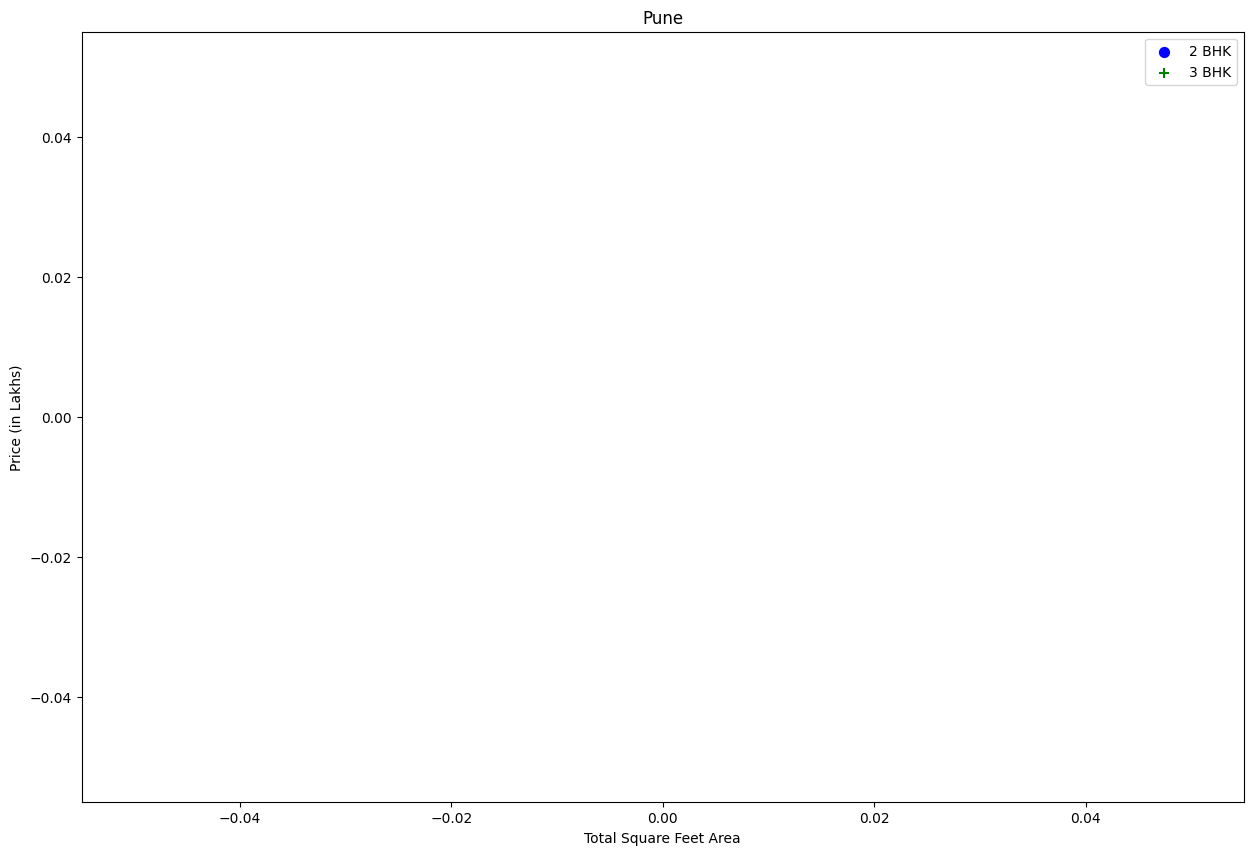

In [37]:
def plot_scatter_chart(df, locality_name):
    bhk2 = df[(df.locality == locality_name) & (df.bedroom == 2)]
    bhk3 = df[(df.locality == locality_name) & (df.bedroom == 3)]
    rcP['figure.figsize'] = (15,10)
    plt.scatter(bhk2.new_area, bhk2.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3.new_area, bhk3.price, color='green', marker='+', label='3 BHK', s=50)
    plt.xlabel('Total Square Feet Area')
    plt.ylabel('Price (in Lakhs)')
    plt.title(locality_name)
    plt.legend()
    
plot_scatter_chart(df3, 'Pune')

In [38]:
# Here we observe that 3 BHK cost that same as 2 BHK in 'Pune' location hence removing such outliers is necessary
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    
    for locality, locality_df in df.groupby('locality'):
        bedroom_stats = {}
        
        for bedroom, bedroom_df in locality_df.groupby('bedroom'):
            bedroom_stats[bedroom] = {
                'mean': np.mean(bedroom_df.price_per_sqft),
                'std': np.std(bedroom_df.price_per_sqft),
                'count': bedroom_df.shape[0]
            }
        
        for bedroom, bedroom_df in locality_df.groupby('bedroom'):
            stats = bedroom_stats.get(bedroom-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bedroom_df[bedroom_df.price_per_sqft<(stats['mean'])].index.values)
    
    return df.drop(exclude_indices, axis='index')

df4 = remove_bhk_outliers(df3)
print(len(df3), len(df4))

170 169


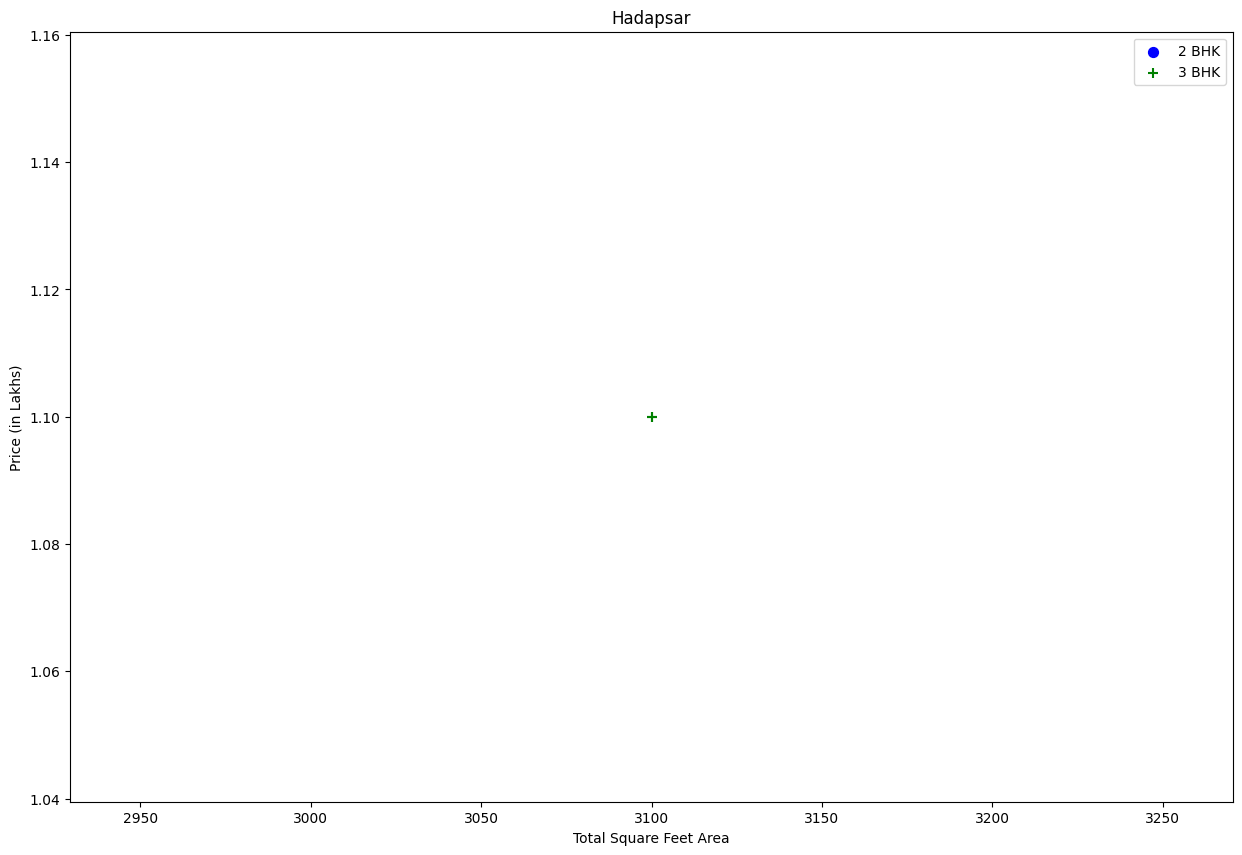

In [39]:
plot_scatter_chart(df4, 'Hadapsar')

Text(0, 0.5, 'Count')

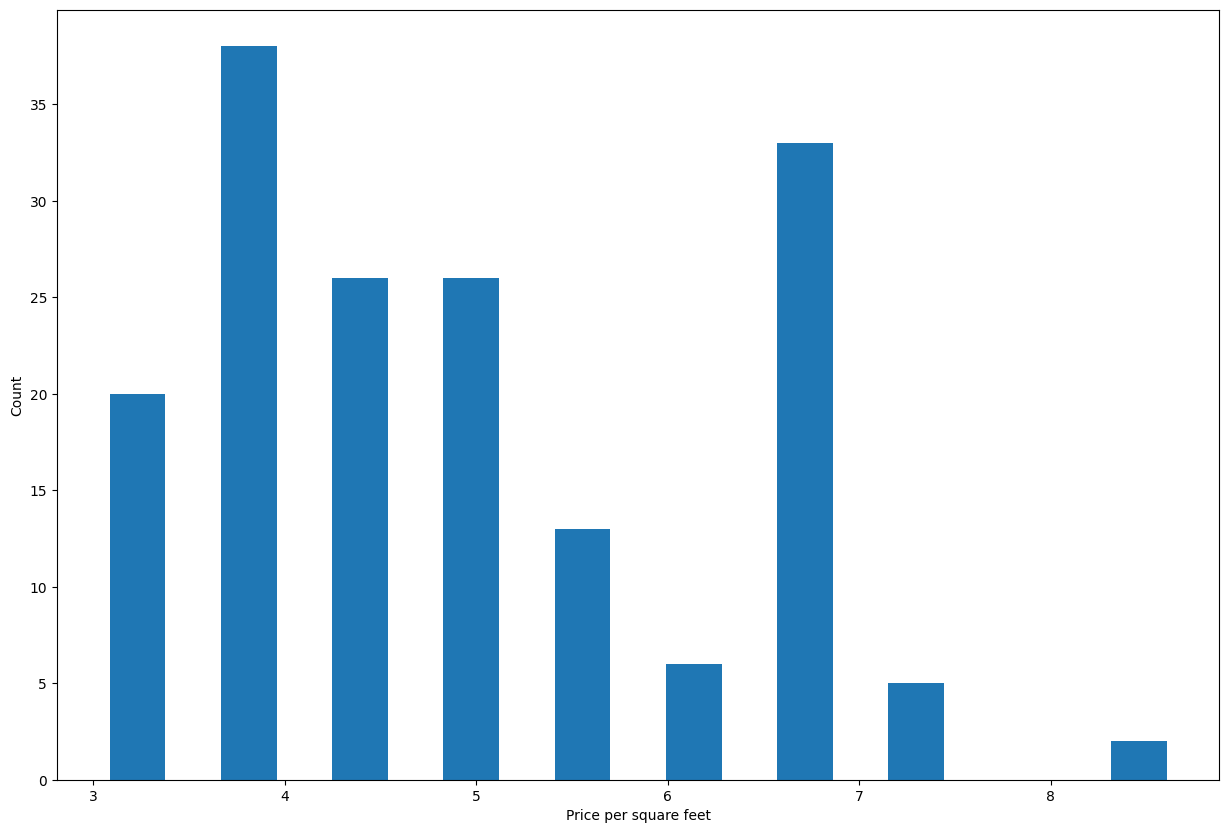

In [40]:
plt.hist(df4.price_per_sqft,rwidth=0.5)
plt.xlabel('Price per square feet')
plt.ylabel('Count')

C:\Users\inter\AppData\Local\Temp\ipykernel_11792\783899643.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df4, x='property_type', y='price', palette='Set2')


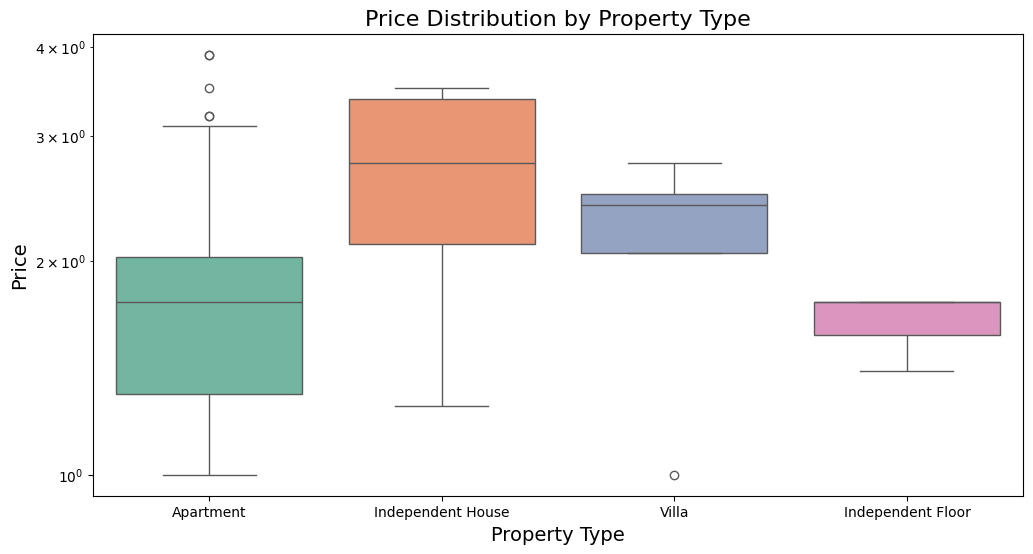

In [41]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df4, x='property_type', y='price', palette='Set2')
plt.title('Price Distribution by Property Type', fontsize=16)
plt.xlabel('Property Type', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.yscale('log')  # Log scale for better visualization of outliers
plt.show()

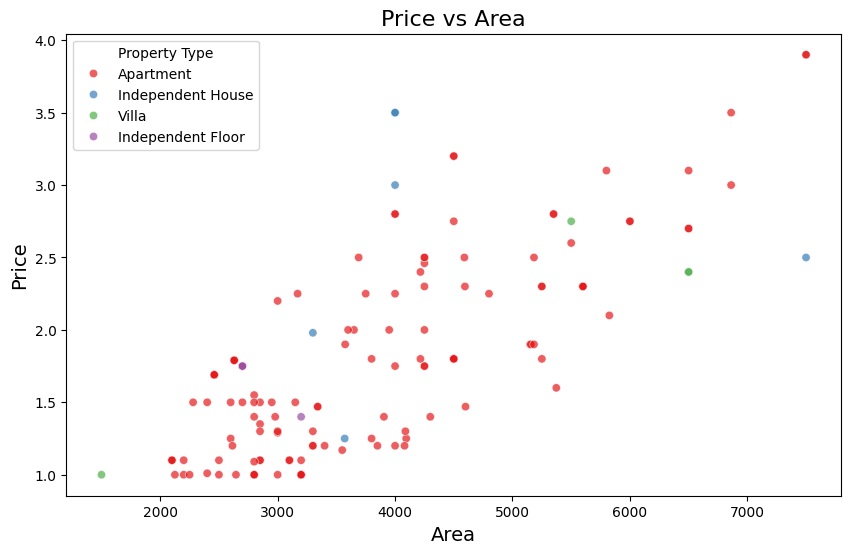

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df4, x='new_area', y='price', hue='property_type', palette='Set1', alpha=0.7)
plt.title('Price vs Area', fontsize=16)
plt.xlabel('Area', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(title='Property Type')
plt.show()

C:\Users\inter\AppData\Local\Temp\ipykernel_11792\2105875110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bedroom_counts.index, y=bedroom_counts.values, palette='cool')


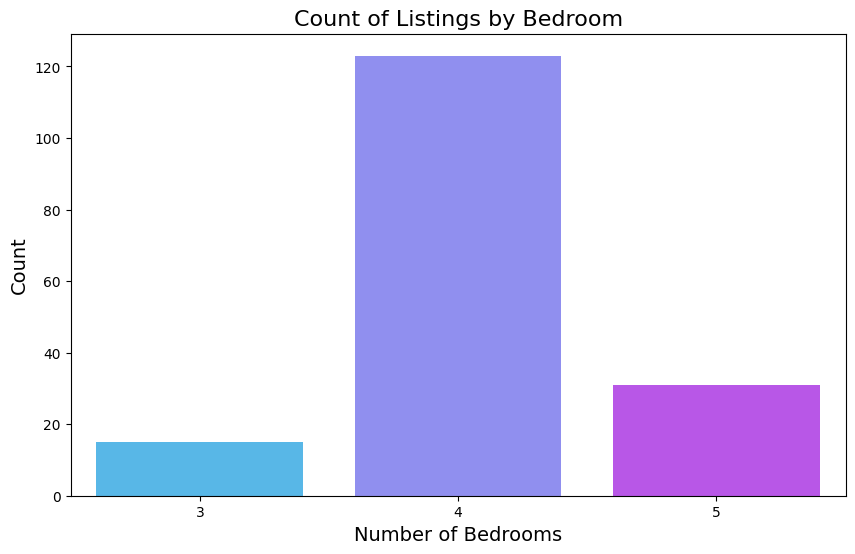

In [43]:
plt.figure(figsize=(10, 6))
bedroom_counts = df4['bedroom'].value_counts().sort_index()
sns.barplot(x=bedroom_counts.index, y=bedroom_counts.values, palette='cool')
plt.title('Count of Listings by Bedroom', fontsize=16)
plt.xlabel('Number of Bedrooms', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

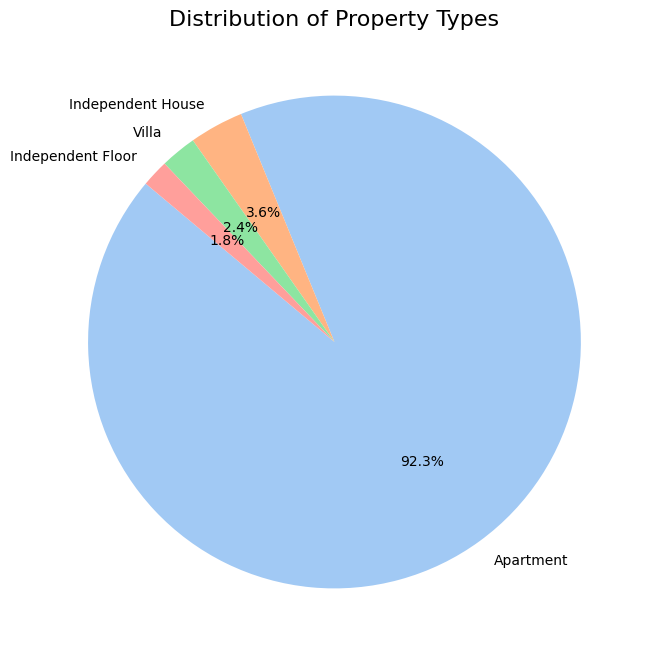

In [44]:
plt.figure(figsize=(8, 8))
property_type_counts = df4['property_type'].value_counts()
plt.pie(property_type_counts, labels=property_type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Property Types', fontsize=16)
plt.show()

Text(0, 0.5, 'Count')

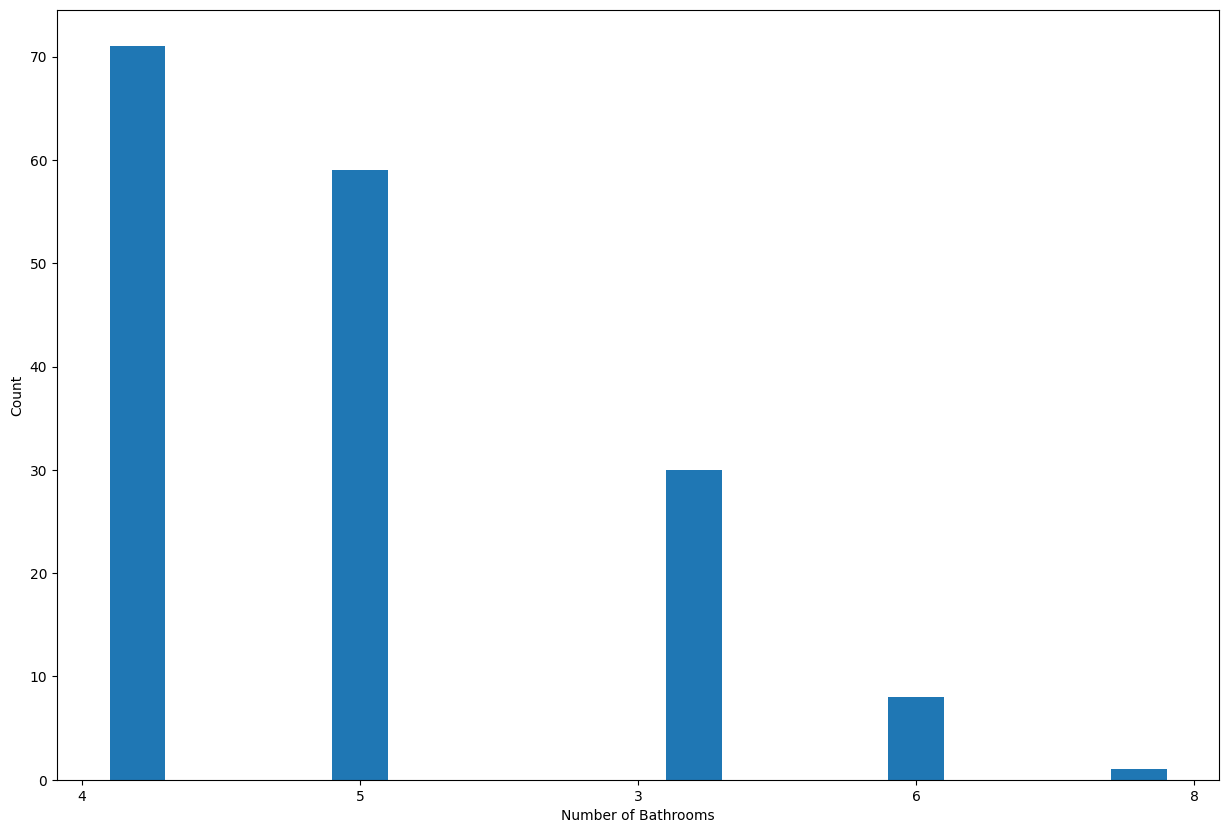

In [45]:
plt.hist(df4.bathroom, rwidth=0.5)
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')

In [46]:
df4['bathroom'] = pd.to_numeric(df4['bathroom'], errors='coerce')
df5=df4[df4.bathroom<(df4.bedroom+2)]
print(len(df4),len(df5))

169 163


In [47]:
df5.tail()

,seller_type,bedroom,layout_type,property_type,locality,price,furnish_type,bathroom,new_area,price_per_sqft
163,AGENT,3,BHK,Apartment,Viman Nagar,1.0,Furnished,3,2500.0,4.000000
166,AGENT,4,BHK,Apartment,other,1.5,Furnished,5,2800.0,5.357143
167,OWNER,4,BHK,Independent House,other,3.0,Semi-Furnished,4,4000.0,7.500000
168,OWNER,5,BHK,Villa,other,1.0,Furnished,4,1500.0,6.666667
169,AGENT,4,BHK,Independent House,other,2.5,Furnished,5,7500.0,3.333333


In [48]:
df6=df5.copy()
df6=df6.drop('price_per_sqft',axis='columns')

In [54]:
df6.head()

,seller_type,bedroom,layout_type,property_type,locality,price,furnish_type,bathroom,new_area,Aundh,...,Kharadi,Koregaon Park,Nigdi,Pashan,Sangamvadi,Sopan Baug,Viman Nagar,other,Furnished,Semi-Furnished
0,AGENT,4,BHK,Apartment,Aundh,2.75,Furnished,4,4500.0,True,...,False,False,False,False,False,False,False,False,True,False
1,OWNER,4,BHK,Independent House,Aundh,3.50,Furnished,5,4000.0,True,...,False,False,False,False,False,False,False,False,True,False
2,OWNER,4,BHK,Independent House,Aundh,3.50,Furnished,5,4000.0,True,...,False,False,False,False,False,False,False,False,True,False
3,AGENT,4,BHK,Apartment,Baner,1.79,Furnished,4,2630.0,False,...,False,False,False,False,False,False,False,False,True,False
4,AGENT,4,BHK,Apartment,Baner,2.25,Furnished,5,3750.0,False,...,False,False,False,False,False,False,False,False,True,False


In [50]:
# Converting the categorical_value into numerical_values using get_dummies method
dummy_cols = pd.get_dummies(df6.locality)
df6 = pd.concat([df6,dummy_cols], axis='columns')

In [51]:
# Converting the categorical_value into numerical_values using get_dummies method
dummy_cols = pd.get_dummies(df6.furnish_type).drop(df6.furnish_type.unique()[-1], axis='columns', errors='ignore')
df6 = pd.concat([df6,dummy_cols], axis='columns')

In [52]:
# Converting the categorical_value into numerical_values using get_dummies method
dummy_cols = pd.get_dummies(df6.layout_type).drop(df6.layout_type.unique()[-1], axis='columns', errors='ignore')
df6 = pd.concat([df6,dummy_cols], axis='columns')

In [62]:
df6.drop(['area_type','availability','site_location'],axis='columns',inplace=True,errors='ignore')
df6.head(10)

,seller_type,bedroom,layout_type,property_type,locality,price,furnish_type,bathroom,new_area,Aundh,...,Kharadi,Koregaon Park,Nigdi,Pashan,Sangamvadi,Sopan Baug,Viman Nagar,other,Furnished,Semi-Furnished
0,AGENT,4,BHK,Apartment,Aundh,2.75,Furnished,4,4500.0,True,...,False,False,False,False,False,False,False,False,True,False
1,OWNER,4,BHK,Independent House,Aundh,3.50,Furnished,5,4000.0,True,...,False,False,False,False,False,False,False,False,True,False
2,OWNER,4,BHK,Independent House,Aundh,3.50,Furnished,5,4000.0,True,...,False,False,False,False,False,False,False,False,True,False
3,AGENT,4,BHK,Apartment,Baner,1.79,Furnished,4,2630.0,False,...,False,False,False,False,False,False,False,False,True,False
4,AGENT,4,BHK,Apartment,Baner,2.25,Furnished,5,3750.0,False,...,False,False,False,False,False,False,False,False,True,False
5,AGENT,4,BHK,Apartment,Baner,2.00,Furnished,5,3650.0,False,...,False,False,False,False,False,False,False,False,True,False
6,AGENT,4,BHK,Apartment,Baner,1.69,Furnished,3,2460.0,False,...,False,False,False,False,False,False,False,False,True,False
7,AGENT,4,BHK,Apartment,Baner,1.69,Furnished,3,2460.0,False,...,False,False,False,False,False,False,False,False,True,False
8,AGENT,4,BHK,Apartment,Baner,1.69,Furnished,3,2460.0,False,...,False,False,False,False,False,False,False,False,True,False
9,AGENT,4,BHK,Apartment,Baner,1.69,Furnished,3,2460.0,False,...,False,False,False,False,False,False,False,False,True,False


In [63]:
df6.shape

(163, 25)

In [65]:
X = df6.drop(['price', 'seller_type', 'layout_type', 'property_type', 'locality', 'furnish_type'], axis='columns')
y = df6['price']
X.head()

,bedroom,bathroom,new_area,Aundh,Baner,Boat Club Road,Gahunje,Hadapsar,Kalyani Nagar,Kharadi,Koregaon Park,Nigdi,Pashan,Sangamvadi,Sopan Baug,Viman Nagar,other,Furnished,Semi-Furnished
0,4,4,4500.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,4,5,4000.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,4,5,4000.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,4,4,2630.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,4,5,3750.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [64]:
# Check data types and find non-numeric columns
print("Data types in df6:")
print(df6.dtypes)
print("\nNon-numeric columns:")
non_numeric_cols = df6.select_dtypes(include=['object']).columns.tolist()
print(non_numeric_cols)

Data types in df6:
seller_type           str
bedroom             int64
layout_type           str
property_type         str
locality              str
price             float64
furnish_type          str
bathroom            int64
new_area          float64
Aundh                bool
Baner                bool
Boat Club Road       bool
Gahunje              bool
Hadapsar             bool
Kalyani Nagar        bool
Kharadi              bool
Koregaon Park        bool
Nigdi                bool
Pashan               bool
Sangamvadi           bool
Sopan Baug           bool
Viman Nagar          bool
other                bool
Furnished            bool
Semi-Furnished       bool
dtype: object

Non-numeric columns:
['seller_type', 'layout_type', 'property_type', 'locality', 'furnish_type']


C:\Users\inter\AppData\Local\Temp\ipykernel_11792\442998794.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_numeric_cols = df6.select_dtypes(include=['object']).columns.tolist()


In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

In [67]:
# Creating a function for GridSearchCV

def find_best_model(X, y):
    models = {
        'linear_regression': {
            'model': LinearRegression(),
            'parameters': {
                
            }
        },
        
        'lasso': {
            'model': Lasso(),
            'parameters': {
                'alpha': [1,2],
                'selection': ['random', 'cyclic']
            }
        },
        
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'parameters': {
                'criterion': ['squared_error', 'absolute_error'],
                'splitter': ['best', 'random']
            }
        }
    }
    
    scores = []
    cv_X_y = ShuffleSplit(n_splits=5, test_size=0.20, random_state=0)
    
    for model_name, model_params in models.items():
        gs = GridSearchCV(model_params['model'], model_params['parameters'], cv=cv_X_y, return_train_score=False)
        gs.fit(X, y)
        scores.append({
            'model': model_name,
            'best_parameters': gs.best_params_,
            'accuracy': gs.best_score_
        })
        
    return pd.DataFrame(scores, columns=['model', 'best_parameters', 'accuracy'])

find_best_model(X, y)

,model,best_parameters,accuracy
0,linear_regression,{},0.675458
1,lasso,"{'alpha': 1, 'selection': 'random'}",0.545744
2,decision_tree,"{'criterion': 'squared_error', 'splitter': 'be...",0.639896


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=20)

In [69]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [70]:
model.score(X_test, y_test)

0.8176144326528025

In [73]:
X.columns

Index(['bedroom', 'bathroom', 'new_area', 'Aundh', 'Baner', 'Boat Club Road',
       'Gahunje', 'Hadapsar', 'Kalyani Nagar', 'Kharadi', 'Koregaon Park',
       'Nigdi', 'Pashan', 'Sangamvadi', 'Sopan Baug', 'Viman Nagar', 'other',
       'Furnished', 'Semi-Furnished'],
      dtype='str')

In [75]:
# Safe way to find column index
column_name = 'Hadapsar'  # Change this to any column you want to find
if column_name in X.columns:
    col_index = X.columns.get_loc(column_name)
    print(f"Index of '{column_name}': {col_index}")
else:
    print(f"Column '{column_name}' not found in X")
    print(f"\nAvailable columns: {list(X.columns)}")

Index of 'Hadapsar': 7


In [77]:
# Safe way to find column index
column_name = 'new_area'  # Change this to any column name (e.g., 'bedroom', 'bathroom', 'new_area', etc.)
if column_name in X.columns:
    col_index = X.columns.get_loc(column_name)
    print(f"Index of '{column_name}': {col_index}")
else:
    print(f"Column '{column_name}' not found in X")
    print(f"\nAvailable columns:\n{list(X.columns)}")

Index of 'new_area': 2


In [82]:
# Predict price for a sample house
# Example: 2 bedroom, 1 bathroom, 800 sqft area, in 'Hadapsar', Furnished
sample = np.zeros((1, X.shape[1]))
sample[0, 0] = 2  # bedroom
sample[0, 1] = 1  # bathroom
sample[0, 2] = 800  # new_area
sample[0, 7] = 1  # Hadapsar (index 7)
sample[0, 18] = 1  # Furnished (index 18)

predicted_price = model.predict(sample)
print(f"Predicted Price: {predicted_price[0]:.2f} Lakhs")

Predicted Price: -0.00 Lakhs


c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [86]:
# Creating a function to predict house price
def prediction(location, bedroom, bathroom, sqft, furnish_type):
    """
    Predict house price based on features.
    
    Parameters:
    - location: e.g., 'Hadapsar', 'Baner', 'Viman Nagar', etc. (or 'other')
    - bedroom: number of bedrooms (int)
    - bathroom: number of bathrooms (int)
    - sqft: area in square feet (float)
    - furnish_type: 'Furnished', 'Semi-Furnished' (or empty for unfurnished)
    
    Valid locations: Aundh, Baner, Boat Club Road, Gahunje, Hadapsar, Kalyani Nagar, 
                    Kharadi, Koregaon Park, Nigdi, Pashan, Sangamvadi, Sopan Baug, 
                    Viman Nagar, other
    """
    
    # Initialize feature array
    x = np.zeros(len(X.columns))
    
    # Set numeric features
    x[X.columns.get_loc('bedroom')] = bedroom
    x[X.columns.get_loc('bathroom')] = bathroom
    x[X.columns.get_loc('new_area')] = sqft
    
    # Set location (default to 'other' if not found)
    if location in X.columns:
        x[X.columns.get_loc(location)] = 1
    elif location != 'other':
        print(f"Warning: Location '{location}' not found. Using 'other'.")
        x[X.columns.get_loc('other')] = 1
    else:
        x[X.columns.get_loc('other')] = 1
    
    # Set furnish type (default to unfurnished if not found)
    if furnish_type in X.columns:
        x[X.columns.get_loc(furnish_type)] = 1
    elif furnish_type:
        print(f"Warning: Furnish type '{furnish_type}' not found. Setting all furnish types to 0.")
    
    return model.predict([x])[0]

In [89]:
# Usage examples with correct parameters
# prediction(location, bedroom, bathroom, sqft, furnish_type)

print("Predict price for a house in Hadapsar:")
price = prediction('Hadapsar', 2, 2, 1000, 'Furnished')
print(f"Predicted Price: {price:.2f} Lakhs")

Predict price for a house in Hadapsar:
Predicted Price: 0.10 Lakhs


c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [91]:
prediction('Hadapsar', 2, 2, 1000, 'Furnished')

c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(0.09882598305313517)

In [94]:
prediction('other', 2, 3, 2000, '')

c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(1.0815625536745326)

In [97]:
prediction('Baner', 2, 3, 2000, '')

c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(1.422112205382344)

In [98]:
import pickle

# Assuming X.columns is a list of all column names in your dataset
locations_list = [col.capitalize() for col in ['aundh', 'baner', 'kothrud', 'wakad', 'hinjewadi', 'pimple_saudagar']]  # Replace with your actual locations
area_types_list = [col.capitalize() for col in ['built_up_area', 'carpet_area', 'plot_area', 'super_built_up_area']]
availability_list = [col.capitalize() for col in ['ready_to_move', 'under_construction', 'not_ready']]

# Generate the dictionary for columns.pkl
data_columns = {
    'data_columns': X.columns.tolist(),  # List of all column names from your model
    'locations': locations_list,         # Dynamically extracted or manually defined
    'area_types': area_types_list,
    'availabilities': availability_list
}

# Save the dictionary to a pickle file
with open('columns.pkl', 'wb') as columns_file:
    pickle.dump(data_columns, columns_file)
print("columns.pkl has been created successfully!")
with open('model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

print("Model saved as model.pkl")

columns.pkl has been created successfully!
Model saved as model.pkl


In [102]:
# Inference function using saved model
import pickle
import os

def load_inference_model():
    """Load the saved model and column mappings"""
    model_path = r'C:\Users\inter\OneDrive\Desktop\sakshi\Machine Learning Project .ipynb\Heart Disease Project\PUNE HOUSE PROJECT\model.pkl'
    columns_path = r'C:\Users\inter\OneDrive\Desktop\sakshi\Machine Learning Project .ipynb\Heart Disease Project\PUNE HOUSE PROJECT\columns.pkl'
    
    if os.path.exists(model_path) and os.path.exists(columns_path):
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
        with open(columns_path, 'rb') as f:
            columns_dict = pickle.load(f)
        # Extract the data_columns list
        data_columns = columns_dict['data_columns']
        return model, data_columns
    else:
        raise FileNotFoundError(f"Model or columns file not found")

def predict_price(location, bedroom, bathroom, sqft, furnish_type):
    """
    Predict house price using the saved model.
    
    Parameters:
    - location: e.g., 'Hadapsar', 'Baner', 'Viman Nagar', etc. (or 'other')
    - bedroom: number of bedrooms (int)
    - bathroom: number of bathrooms (int)
    - sqft: area in square feet (float)
    - furnish_type: 'Furnished', 'Semi-Furnished' (or empty string for unfurnished)
    
    Returns:
    - Predicted price in Lakhs (float)
    """
    try:
        model, data_columns = load_inference_model()
        
        # Initialize feature array with zeros
        x = np.zeros(len(data_columns))
        
        # Set numeric features
        x[data_columns.index('bedroom')] = bedroom
        x[data_columns.index('bathroom')] = bathroom
        x[data_columns.index('new_area')] = sqft
        
        # Set location
        if location in data_columns:
            x[data_columns.index(location)] = 1
        elif location != 'other':
            print(f"Warning: Location '{location}' not found. Using 'other'.")
            if 'other' in data_columns:
                x[data_columns.index('other')] = 1
        else:
            if 'other' in data_columns:
                x[data_columns.index('other')] = 1
        
        # Set furnish type
        if furnish_type and furnish_type in data_columns:
            x[data_columns.index(furnish_type)] = 1
        
        # Make prediction
        predicted_price = model.predict([x])[0]
        return float(predicted_price)
    
    except Exception as e:
        print(f"Error during prediction: {e}")
        return None

# Test the inference function
print("Testing Inference Function with Saved Model:")
print("=" * 50)

test_cases = [
    ('Hadapsar', 2, 2, 1000, 'Furnished'),
    ('Baner', 3, 2, 1500, 'Semi-Furnished'),
    ('other', 2, 1, 800, ''),
]

for location, bed, bath, area, furnish in test_cases:
    price = predict_price(location, bed, bath, area, furnish)
    if price is not None:
        print(f"Location: {location}, Bedrooms: {bed}, Bathrooms: {bath}, Area: {area} sqft, Furnish: {furnish}")
        print(f"Predicted Price: {price:.2f} Lakhs\n")

Testing Inference Function with Saved Model:
Location: Hadapsar, Bedrooms: 2, Bathrooms: 2, Area: 1000 sqft, Furnish: Furnished
Predicted Price: 0.10 Lakhs

Location: Baner, Bedrooms: 3, Bathrooms: 2, Area: 1500 sqft, Furnish: Semi-Furnished
Predicted Price: 1.14 Lakhs

Location: other, Bedrooms: 2, Bathrooms: 1, Area: 800 sqft, Furnish: 
Predicted Price: 0.56 Lakhs



c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [101]:
# Check the structure of saved columns.pkl
import pickle

columns_path = r'C:\Users\inter\OneDrive\Desktop\sakshi\Machine Learning Project .ipynb\Heart Disease Project\PUNE HOUSE PROJECT\columns.pkl'

with open(columns_path, 'rb') as f:
    data_columns_dict = pickle.load(f)

print("Type of data_columns:", type(data_columns_dict))
print("First 10 items:", dict(list(data_columns_dict.items())[:10]))

Type of data_columns: <class 'dict'>
First 10 items: {'data_columns': ['bedroom', 'bathroom', 'new_area', 'Aundh', 'Baner', 'Boat Club Road', 'Gahunje', 'Hadapsar', 'Kalyani Nagar', 'Kharadi', 'Koregaon Park', 'Nigdi', 'Pashan', 'Sangamvadi', 'Sopan Baug', 'Viman Nagar', 'other', 'Furnished', 'Semi-Furnished'], 'locations': ['Aundh', 'Baner', 'Kothrud', 'Wakad', 'Hinjewadi', 'Pimple_saudagar'], 'area_types': ['Built_up_area', 'Carpet_area', 'Plot_area', 'Super_built_up_area'], 'availabilities': ['Ready_to_move', 'Under_construction', 'Not_ready']}
